In [1]:
%cd ..
%load_ext autoreload
%autoreload 2

/home/dongmin/userdata/open-score-string-quartets


/home/dongmin/.local/share/virtualenvs/open-score-string-quartets-wd2Cnojv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [22]:
import os
import sys
import subprocess
import warnings
from typing import Union, Any, Optional
import shutil
from pathlib import Path
from collections import Counter, defaultdict
from operator import itemgetter, contains, eq # contains(A, B) == (B in A), eq(A, B) == (A == B)
from itertools import groupby
from tempfile import NamedTemporaryFile, TemporaryDirectory

import math
import random

import json
import csv
import strictyaml as syaml

from tqdm import tqdm
import matplotlib.pyplot as plt

import cv2
import numpy as np

import xml.etree.ElementTree as ET
from ultralytics import YOLO

from modules.svdp.svdp import bbox_utils

dformat = lambda d: json.dumps(d, indent=2)
dprint = lambda d: print(dformat(d))

In [3]:
prj_root = Path.cwd()
data_dir = prj_root / 'data'
score_dir = prj_root / 'scores'

In [4]:
data_dir, score_dir

(PosixPath('/home/dongmin/userdata/open-score-string-quartets/data'),
 PosixPath('/home/dongmin/userdata/open-score-string-quartets/scores'))

## Load YOLO model

In [6]:
weight_path = prj_root / 'modules' / 'lsyolo' / 'checkpoints' / 'ls-yolo-system-v2.pt'
weight_path.exists()

True

In [15]:
model = YOLO('yolov8m.pt')
model._load(weights=str(weight_path))

## Test on some images

In [8]:
page_imgs = score_dir.glob('**/images/original/*.png')
page_imgs = list(sorted(page_imgs))

len(page_imgs), page_imgs[:3]

(2911,
 [PosixPath('/home/dongmin/userdata/open-score-string-quartets/scores/Andrée,_Elfrida/String_Quartet_in_A_major/images/original/sq7313978:0001.png'),
  PosixPath('/home/dongmin/userdata/open-score-string-quartets/scores/Andrée,_Elfrida/String_Quartet_in_A_major/images/original/sq7313978:0002.png'),
  PosixPath('/home/dongmin/userdata/open-score-string-quartets/scores/Andrée,_Elfrida/String_Quartet_in_A_major/images/original/sq7313978:0003.png')])

In [9]:
random.seed(42)

test_imgs = random.sample(page_imgs, 10)

all([p.exists() for p in test_imgs])

True

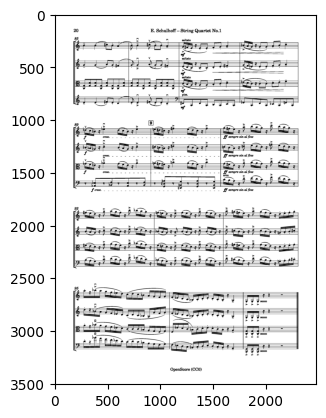

In [11]:
plt.imshow(cv2.imread(test_imgs[0], cv2.IMREAD_UNCHANGED))

In [16]:
results = model(test_imgs)

/home/dongmin/.local/share/virtualenvs/open-score-string-quartets-wd2Cnojv/lib/python3.10/site-packages/torch/cuda/__init__.py:619: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


0: 640x480 4 systems, 102.4ms
1: 640x480 3 systems, 102.4ms
2: 640x480 5 systems, 102.4ms
3: 640x480 5 systems, 102.4ms
4: 640x480 5 systems, 102.4ms
5: 640x480 5 systems, 102.4ms
6: 640x480 5 systems, 102.4ms
7: 640x480 4 systems, 102.4ms
8: 640x480 5 systems, 102.4ms
9: 640x480 5 systems, 102.4ms
Speed: 1.4ms preprocess, 102.4ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 480)
Speed: 1.4ms preprocess, 102.4ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 480)


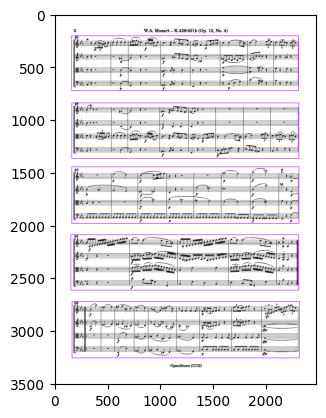

In [29]:
result = results[9]

orig_path = Path(result.path)
orig_fn = orig_path.stem
bboxs = result.boxes.xyxy
bboxs = bboxs.int().tolist()

# sort by y, x
bboxs = sorted( bboxs, key=lambda x: (x[1], x[0]) )

img = cv2.imread(orig_path, cv2.IMREAD_UNCHANGED)

for i, (lx, ly, rx, ry) in enumerate(bboxs):
  cv2.rectangle(img, (lx, ly), (rx, ry), (180, 0, 255), 3)

plt.imshow(img)

# save bboxs
# o_dir = orig_path.parent.parent / 'cropped'

# if not o_dir.exists():
#   o_dir.mkdir()

# with open( o_dir / f'{orig_fn}.txt', 'w') as f:
#   for lx, ly, rx, ry in bboxs:
#     f.write(f'{lx} {ly} {rx} {ry}\n')

## Compare results with n_system metadata

In [5]:
bbox_paths = score_dir.glob('**/images/original/*systems.txt')
bbox_paths = list(sorted(bbox_paths))

In [6]:
bbox_paths[:2]

[PosixPath('/home/dongmin/userdata/open-score-string-quartets/scores/Andrée,_Elfrida/String_Quartet_in_A_major/images/original/sq7313978:0001_systems.txt'),
 PosixPath('/home/dongmin/userdata/open-score-string-quartets/scores/Andrée,_Elfrida/String_Quartet_in_A_major/images/original/sq7313978:0002_systems.txt')]

In [7]:
with open(data_dir / 'scores_w_infos.yaml', 'r') as f:
  data = syaml.load(f.read())

data = data.data

In [23]:
error_pages = []

for b_p in tqdm(bbox_paths):
  with open(b_p, 'r') as f:
    bboxs = f.readlines()
  
  bboxs = [
    [ int(c) for c in b.split() ]
    for b in bboxs
  ]

  # sort by y, x
  bboxs = sorted( bboxs, key=lambda x: (x[1], x[0]) )
  
  bboxs = bbox_utils.merge_match_bboxs(bboxs)
  
  pred = len(bboxs)

  sqid, pidx = b_p.stem.split(':')
  sqid = sqid.replace('sq', '')
  pidx = int(pidx.split('_')[0]) - 1
  n_systems = int(data[sqid]['n_systems'][pidx])
  
  if pred != n_systems:
    img_path = b_p.parent / b_p.name.replace('_systems.txt', '.png')
    error_pages.append((img_path, n_systems, pred, bboxs))

100%|██████████| 2897/2897 [00:00<00:00, 45777.13it/s]


In [24]:
len(error_pages)

8

In [26]:
error_pages

[(PosixPath('/home/dongmin/userdata/open-score-string-quartets/scores/Andrée,_Elfrida/String_Quartet_in_A_major/images/original/sq7313978:0010.png'),
  5,
  4,
  [[194, 312, 2317, 957],
   [158, 965, 2317, 1574],
   (154, 1578, 2318, 2620),
   [158, 2639, 2324, 3245]]),
 (PosixPath('/home/dongmin/userdata/open-score-string-quartets/scores/Borodin,_Alexander/String_Quartet_No.1/images/original/sq8811375:0035.png'),
  5,
  2,
  [[157, 211, 2316, 808], (148, 623, 2324, 3365)]),
 (PosixPath('/home/dongmin/userdata/open-score-string-quartets/scores/Borodin,_Alexander/String_Quartet_No.1/images/original/sq8811375:0045.png'),
  5,
  4,
  [[157, 209, 2311, 772],
   [158, 788, 2310, 1366],
   [156, 1361, 2318, 1969],
   [152, 1968, 2318, 3266]]),
 (PosixPath('/home/dongmin/userdata/open-score-string-quartets/scores/Borodin,_Alexander/String_Quartet_No.2/images/original/sq10675759:0028.png'),
  5,
  3,
  [[161, 218, 2312, 841], [160, 829, 2312, 1475], [165, 1473, 2317, 2082]]),
 (PosixPath('/hom

In [ ]:
for img_path, n_systems, pred, bboxs in error_pages:  
  print(n_systems, pred)
  img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)

  for i, (lx, ly, rx, ry) in enumerate(bboxs):
    cv2.rectangle(img, (lx, ly), (rx, ry), (180, 0, 255), 3)

  fig = plt.figure(figsize=(12, 8))
  gs = fig.add_gridspec(len(bboxs), 2, width_ratios=[2, 1], hspace=0.3)

  ax_large = fig.add_subplot(gs[:, 0])
  ax_large.imshow(img)

  for i, (lx, ly, rx, ry) in enumerate(bboxs):
    ax_small = fig.add_subplot(gs[i, 1])
    ax_small.imshow(img[ly:ry, lx:rx])

  plt.tight_layout()
  plt.show()

## Compare n_system metadata with lmxe

In [27]:
lmxe_paths = score_dir.glob('**/lmxe/*.lmxe')
lmxe_paths = list(sorted(lmxe_paths))
len(lmxe_paths), lmxe_paths[:3]

(2897,
 [PosixPath('/home/dongmin/userdata/open-score-string-quartets/scores/Andrée,_Elfrida/String_Quartet_in_A_major/lmxe/sq7313978:0001.lmxe'),
  PosixPath('/home/dongmin/userdata/open-score-string-quartets/scores/Andrée,_Elfrida/String_Quartet_in_A_major/lmxe/sq7313978:0002.lmxe'),
  PosixPath('/home/dongmin/userdata/open-score-string-quartets/scores/Andrée,_Elfrida/String_Quartet_in_A_major/lmxe/sq7313978:0003.lmxe')])

In [30]:
with open(lmxe_paths[0], 'r') as f:
  lmxe = f.read()

systems = lmxe.split('\n\n')

In [32]:
systems[0].split('\n')

['measure part:1 key:fifths:3 time beats:4 beat-type:4 clef:G2 A4 voice:1 half stem:up tied:start A4 eighth beam:begin tied:stop B4 16th beam:begin slur:start B4 16th sharp beam:end beam:end C5 16th stem:down beam:begin beam:begin D5 16th D5 16th sharp F5 16th beam:end beam:end part:2 key:fifths:3 time beats:4 beat-type:4 clef:G2 A4 voice:1 half stem:up tied:start A4 eighth beam:begin tied:stop B4 16th beam:begin slur:start B4 16th sharp beam:end beam:end C5 16th stem:down beam:begin beam:begin D5 16th D5 16th sharp F5 16th beam:end beam:end part:3 key:fifths:3 time beats:4 beat-type:4 clef:C3 A3 voice:1 half stem:up tied:start A3 eighth beam:begin tied:stop B3 16th beam:begin slur:start B3 16th sharp beam:end beam:end C4 16th stem:down beam:begin beam:begin D4 16th D4 16th sharp F4 16th beam:end beam:end part:4 key:fifths:3 time beats:4 beat-type:4 clef:F4 A3 voice:1 half stem:down tied:start A3 eighth beam:begin tied:stop B3 16th beam:begin slur:start B3 16th sharp beam:end beam:end 

In [33]:
error_lmxe = []

for l_p in tqdm(lmxe_paths):
  with open(l_p, 'r') as f:
    lmxe = f.read()
  
  systems = lmxe.split('\n\n')
  
  pred = len(systems)

  sqid, pidx = l_p.stem.split(':')
  sqid = sqid.replace('sq', '')
  pidx = int(pidx.split('_')[0]) - 1
  n_systems = int(data[sqid]['n_systems'][pidx])
  
  if pred != n_systems:
    img_path = l_p.parent.parent / 'images' / 'original' / f'{l_p.stem}.png'
    error_lmxe.append((img_path, n_systems, pred))

100%|██████████| 2897/2897 [00:00<00:00, 53326.39it/s]


In [34]:
len(error_lmxe)

0